# ⛏️ Mining Process Flotation — ML Regression Pipeline
**Target:** Predict `% Silica Concentrate` (lower is better quality iron ore)

**Models:** LightGBM · XGBoost · Random Forest · Ridge · Extra Trees  
**Best model** is auto-selected by R² and packaged for Streamlit.

## 1. Imports & Setup

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import json
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

RANDOM_STATE = 42
TARGET = '% Silica Concentrate'
print('All libraries loaded ✅')

All libraries loaded ✅


## 2. Load Data

In [36]:
# ── Change this path to your actual file ──
FILE_PATH = 'archive/MiningProcess_Flotation_Plant_Database.csv'

df = pd.read_csv(FILE_PATH, sep=',', decimal=',')

# Strip whitespace from column names
df.columns = df.columns.str.strip()

print(f'Shape: {df.shape}')
df.head()

Shape: (737453, 24)


,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-10 01:00:00,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74,249.214,253.235,...,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
1,2017-03-10 01:00:00,55.2,16.98,3024.41,563.965,397.383,10.0672,1.74,249.719,250.532,...,248.994,451.891,429.560,432.939,448.086,496.363,445.922,498.075,66.91,1.31
2,2017-03-10 01:00:00,55.2,16.98,3043.46,568.054,399.668,10.0680,1.74,249.741,247.874,...,248.071,451.240,468.927,434.610,449.688,484.411,447.826,458.567,66.91,1.31
3,2017-03-10 01:00:00,55.2,16.98,3047.36,568.665,397.939,10.0689,1.74,249.917,254.487,...,251.147,452.441,458.165,442.865,446.210,471.411,437.690,427.669,66.91,1.31
4,2017-03-10 01:00:00,55.2,16.98,3033.69,558.167,400.254,10.0697,1.74,250.203,252.136,...,248.928,452.441,452.900,450.523,453.670,462.598,443.682,425.679,66.91,1.31


## 3. Basic Info & Drop Unnecessary Columns

In [37]:
print(df.dtypes)
print('\nNull counts:')
print(df.isnull().sum())

date                                str
% Iron Feed                     float64
% Silica Feed                   float64
Starch Flow                     float64
Amina Flow                      float64
Ore Pulp Flow                   float64
Ore Pulp pH                     float64
Ore Pulp Density                float64
Flotation Column 01 Air Flow    float64
Flotation Column 02 Air Flow    float64
Flotation Column 03 Air Flow    float64
Flotation Column 04 Air Flow    float64
Flotation Column 05 Air Flow    float64
Flotation Column 06 Air Flow    float64
Flotation Column 07 Air Flow    float64
Flotation Column 01 Level       float64
Flotation Column 02 Level       float64
Flotation Column 03 Level       float64
Flotation Column 04 Level       float64
Flotation Column 05 Level       float64
Flotation Column 06 Level       float64
Flotation Column 07 Level       float64
% Iron Concentrate              float64
% Silica Concentrate            float64
dtype: object

Null counts:
date        

In [38]:
# Drop the datetime column (not useful as-is for regression)
# Also drop '% Iron Concentrate' — it's a co-output, not an input
COLS_TO_DROP = ['date', '% Iron Concentrate']
COLS_TO_DROP = [c for c in COLS_TO_DROP if c in df.columns]

df.drop(columns=COLS_TO_DROP, inplace=True)
print(f'Dropped: {COLS_TO_DROP}')
print(f'Remaining columns ({len(df.columns)}): {df.columns.tolist()}')

Dropped: ['date', '% Iron Concentrate']
Remaining columns (22): ['% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow', 'Ore Pulp Flow', 'Ore Pulp pH', 'Ore Pulp Density', 'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow', 'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow', 'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow', 'Flotation Column 07 Air Flow', 'Flotation Column 01 Level', 'Flotation Column 02 Level', 'Flotation Column 03 Level', 'Flotation Column 04 Level', 'Flotation Column 05 Level', 'Flotation Column 06 Level', 'Flotation Column 07 Level', '% Silica Concentrate']


In [39]:
# Ensure all columns are numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('All columns converted to numeric ✅')
df.describe().T

All columns converted to numeric ✅


,count,mean,std,min,25%,50%,75%,max
% Iron Feed,737453.0,56.294739,5.157744,42.740000,52.670000,56.080000,59.720000,65.78000
% Silica Feed,737453.0,14.651716,6.807439,1.310000,8.940000,13.850000,19.600000,33.40000
Starch Flow,737453.0,2869.140569,1215.203734,0.002026,2076.320000,3018.430000,3727.730000,6300.23000
Amina Flow,737453.0,488.144697,91.230534,241.669000,431.796000,504.393000,553.257000,739.53800
Ore Pulp Flow,737453.0,397.578372,9.699785,376.249000,394.264000,399.249000,402.968000,418.64100
Ore Pulp pH,737453.0,9.767639,0.387007,8.753340,9.527360,9.798100,10.038000,10.80810
Ore Pulp Density,737453.0,1.680380,0.069249,1.519820,1.647310,1.697600,1.728330,1.85325
Flotation Column 01 Air Flow,737453.0,280.151856,29.621288,175.510000,250.281000,299.344000,300.149000,373.87100
Flotation Column 02 Air Flow,737453.0,277.159965,30.149357,175.156000,250.457000,296.223000,300.690000,375.99200
Flotation Column 03 Air Flow,737453.0,281.082397,28.558268,176.469000,250.855000,298.696000,300.382000,364.34600


## 4. Exploratory Data Analysis (EDA)

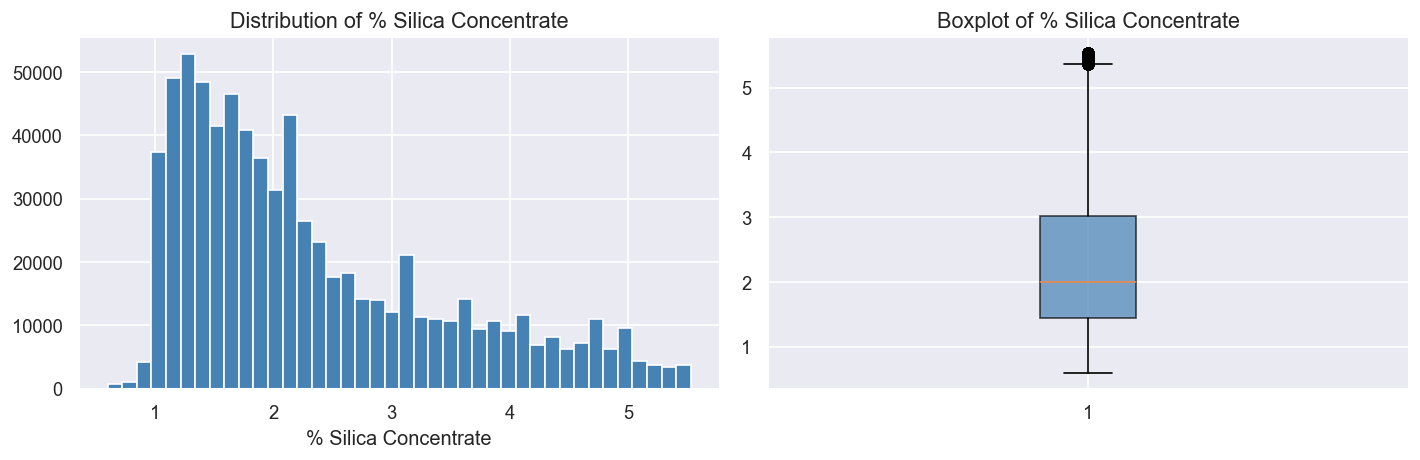

In [40]:
# ── 4.1 Target Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df[TARGET], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title(f'Distribution of {TARGET}', fontsize=13)
axes[0].set_xlabel(TARGET)

axes[1].boxplot(df[TARGET].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title(f'Boxplot of {TARGET}', fontsize=13)
plt.tight_layout()
plt.savefig('plot_target_distribution.png', bbox_inches='tight')
plt.show()

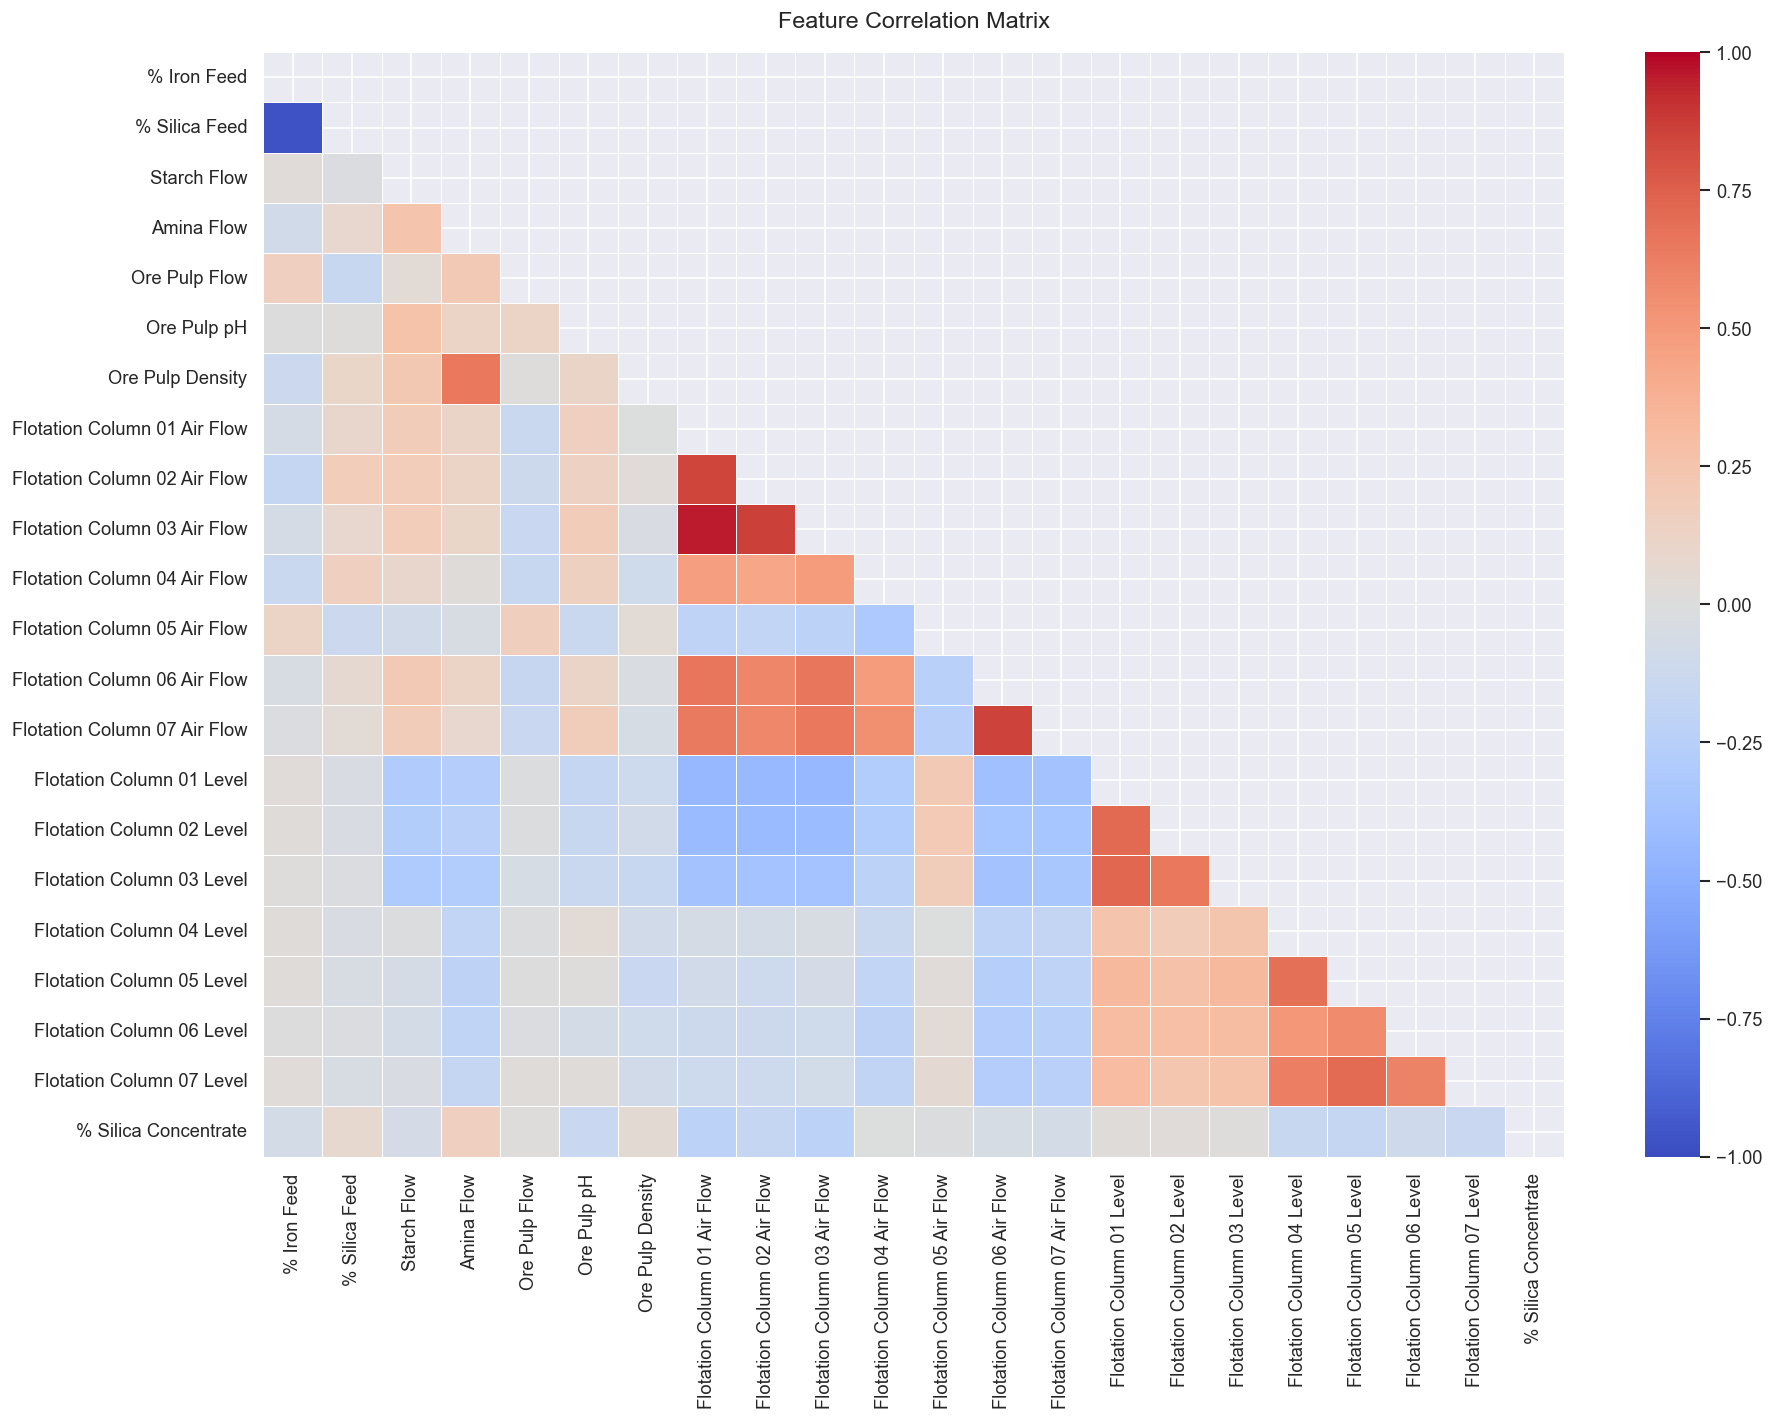

In [41]:
# ── 4.2 Correlation Heatmap ──
plt.figure(figsize=(16, 12))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm',
            center=0, linewidths=0.3, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('plot_correlation_heatmap.png', bbox_inches='tight')
plt.show()

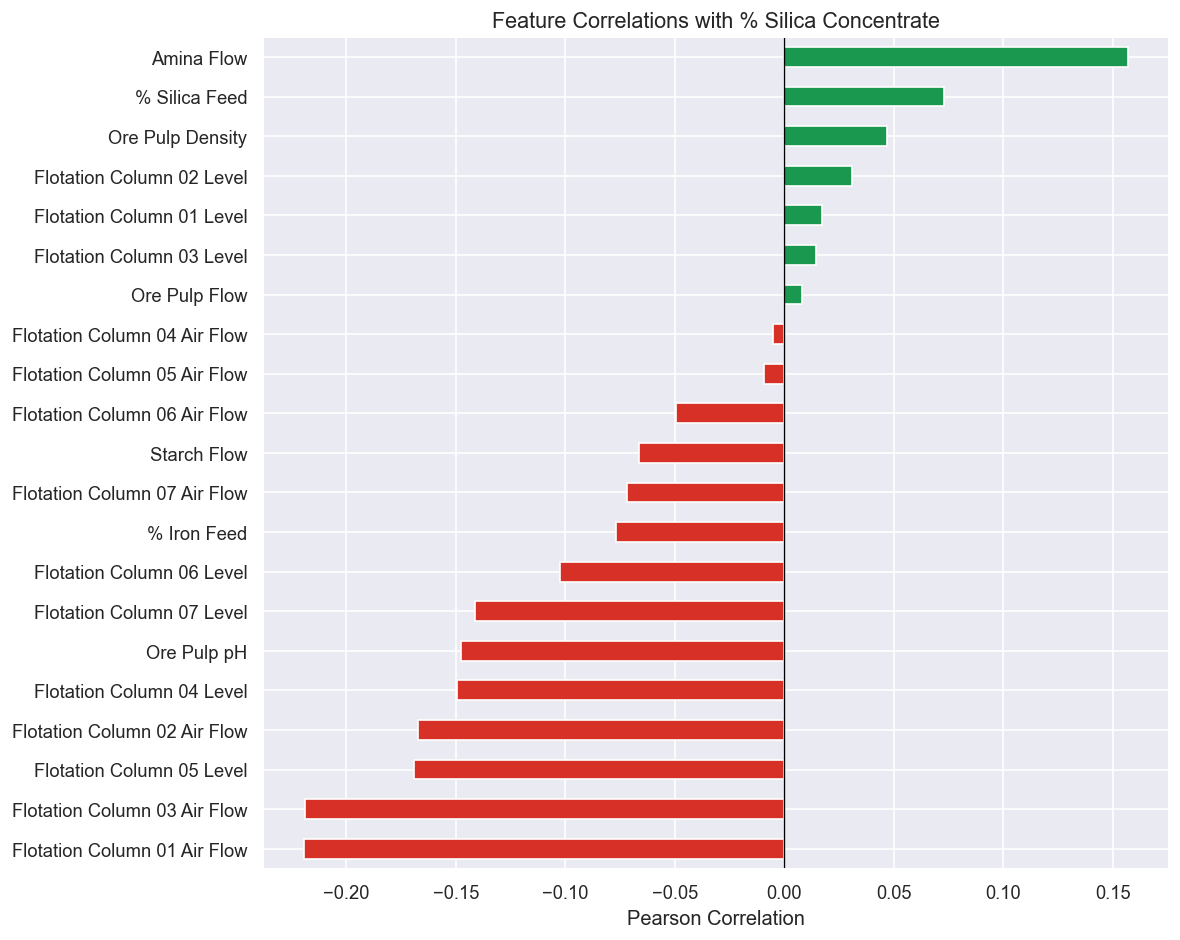

In [42]:
# ── 4.3 Top Correlations with Target ──
target_corr = corr[TARGET].drop(TARGET).sort_values()
colors = ['#d73027' if v < 0 else '#1a9850' for v in target_corr]

plt.figure(figsize=(10, 8))
target_corr.plot(kind='barh', color=colors, edgecolor='white')
plt.title(f'Feature Correlations with {TARGET}', fontsize=13)
plt.xlabel('Pearson Correlation')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('plot_target_correlations.png', bbox_inches='tight')
plt.show()

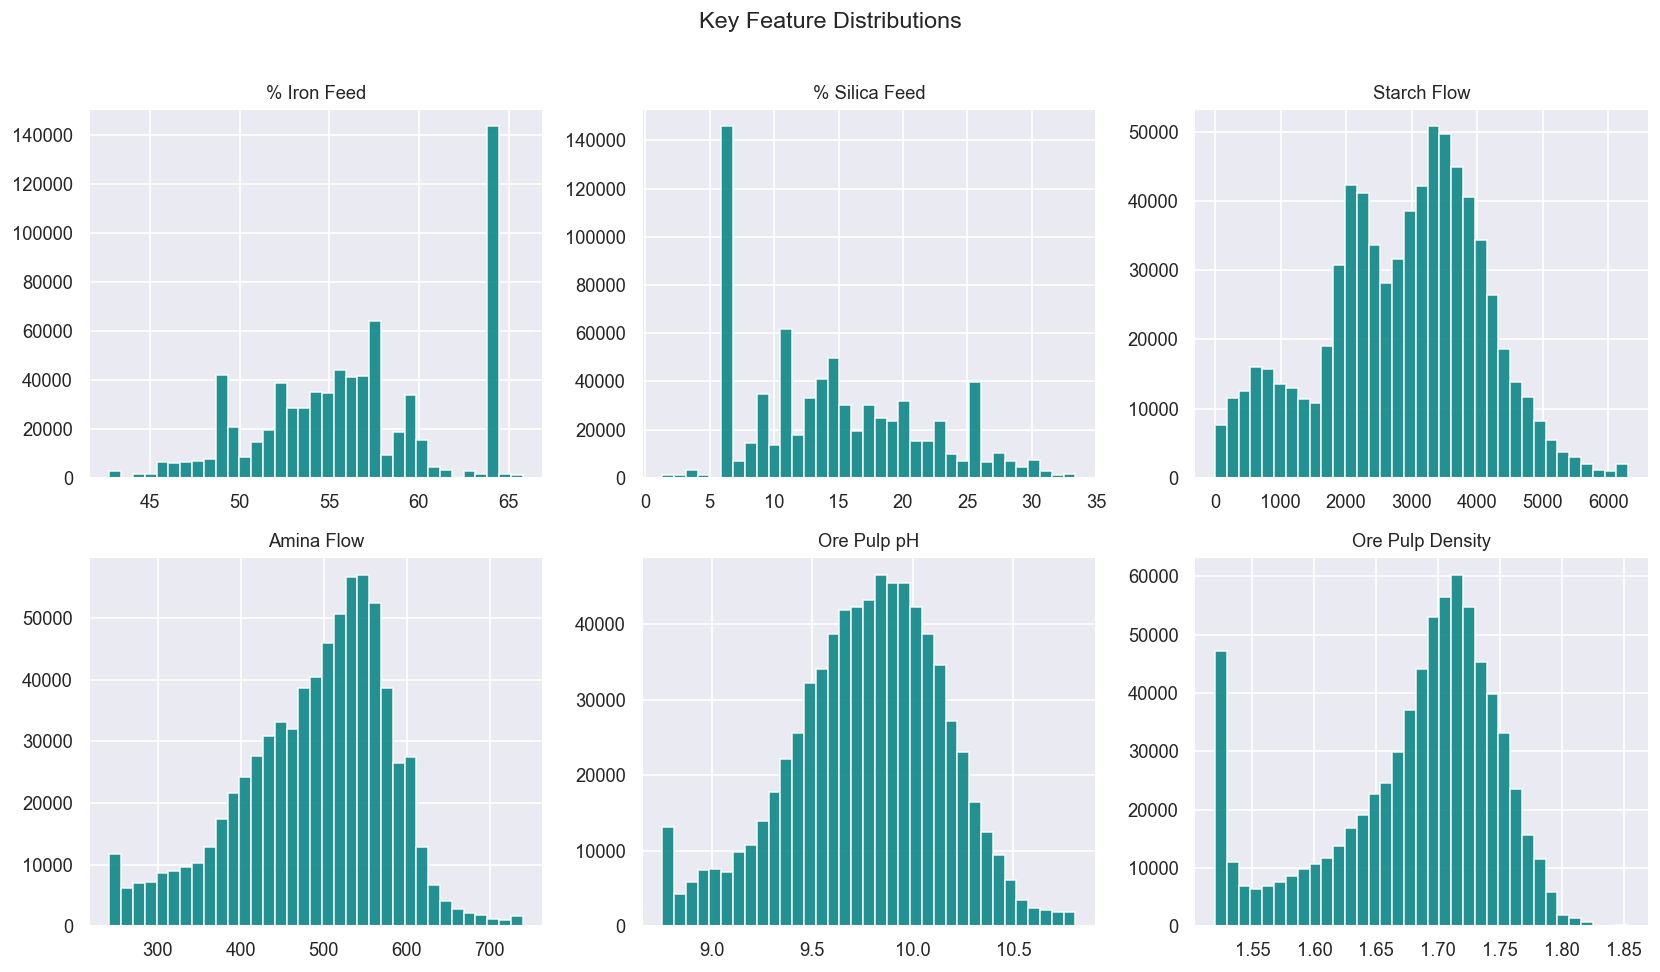

In [43]:
# ── 4.4 Feature Distributions (key features) ──
key_features = ['% Iron Feed', '% Silica Feed', 'Starch Flow',
                'Amina Flow', 'Ore Pulp pH', 'Ore Pulp Density']
key_features = [f for f in key_features if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, feat in enumerate(key_features):
    axes[i].hist(df[feat].dropna(), bins=35, color='teal', edgecolor='white', alpha=0.85)
    axes[i].set_title(feat, fontsize=11)
plt.suptitle('Key Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plot_feature_distributions.png', bbox_inches='tight')
plt.show()

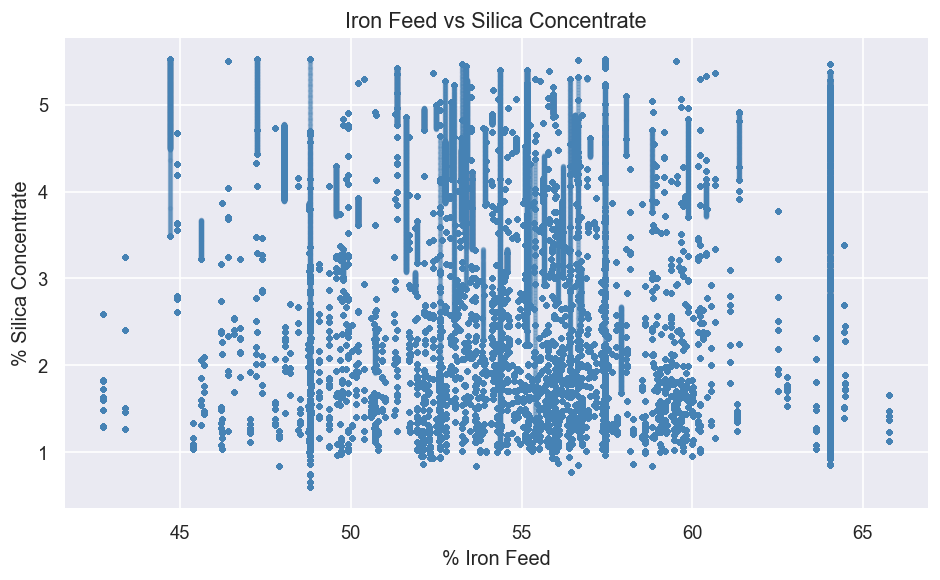

In [44]:
# ── 4.5 Scatter: Iron Feed vs Silica Concentrate ──
if '% Iron Feed' in df.columns:
    plt.figure(figsize=(8, 5))
    plt.scatter(df['% Iron Feed'], df[TARGET], alpha=0.2, s=5, color='steelblue')
    plt.xlabel('% Iron Feed')
    plt.ylabel('% Silica Concentrate')
    plt.title('Iron Feed vs Silica Concentrate', fontsize=13)
    plt.tight_layout()
    plt.savefig('plot_scatter_iron_vs_silica.png', bbox_inches='tight')
    plt.show()

## 5. Impute Missing Values

In [45]:
missing_before = df.isnull().sum().sum()
print(f'Total missing values before imputation: {missing_before}')

imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

missing_after = df_imputed.isnull().sum().sum()
print(f'Total missing values after imputation: {missing_after} ✅')

Total missing values before imputation: 0
Total missing values after imputation: 0 ✅


## 6. Train / Test Split

In [46]:
X = df_imputed.drop(columns=[TARGET])
y = df_imputed[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

# Save feature names for Streamlit
FEATURE_NAMES = X.columns.tolist()
print(f'Features ({len(FEATURE_NAMES)}): {FEATURE_NAMES}')

Train: (589962, 21)  |  Test: (147491, 21)
Features (21): ['% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow', 'Ore Pulp Flow', 'Ore Pulp pH', 'Ore Pulp Density', 'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow', 'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow', 'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow', 'Flotation Column 07 Air Flow', 'Flotation Column 01 Level', 'Flotation Column 02 Level', 'Flotation Column 03 Level', 'Flotation Column 04 Level', 'Flotation Column 05 Level', 'Flotation Column 06 Level', 'Flotation Column 07 Level']


## 7. Train & Compare Models

In [47]:
models = {
    'LightGBM': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LGBMRegressor(n_estimators=500, learning_rate=0.05,
                                num_leaves=63, random_state=RANDOM_STATE, verbose=-1))
    ]),
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('model', XGBRegressor(n_estimators=500, learning_rate=0.05,
                               max_depth=6, random_state=RANDOM_STATE,
                               verbosity=0))
    ]),
}

results = {}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    r2  = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)
    results[name] = {'R2': r2, 'RMSE': rmse, 'MAE': mae, 'pipeline': pipeline}
    print(f'{name:15s}  R²={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}')

print('\nAll models trained ✅')

LightGBM         R²=0.8021  RMSE=0.5001  MAE=0.3612
XGBoost          R²=0.7146  RMSE=0.6006  MAE=0.4325

All models trained ✅


## 8. Visualise Model Comparison

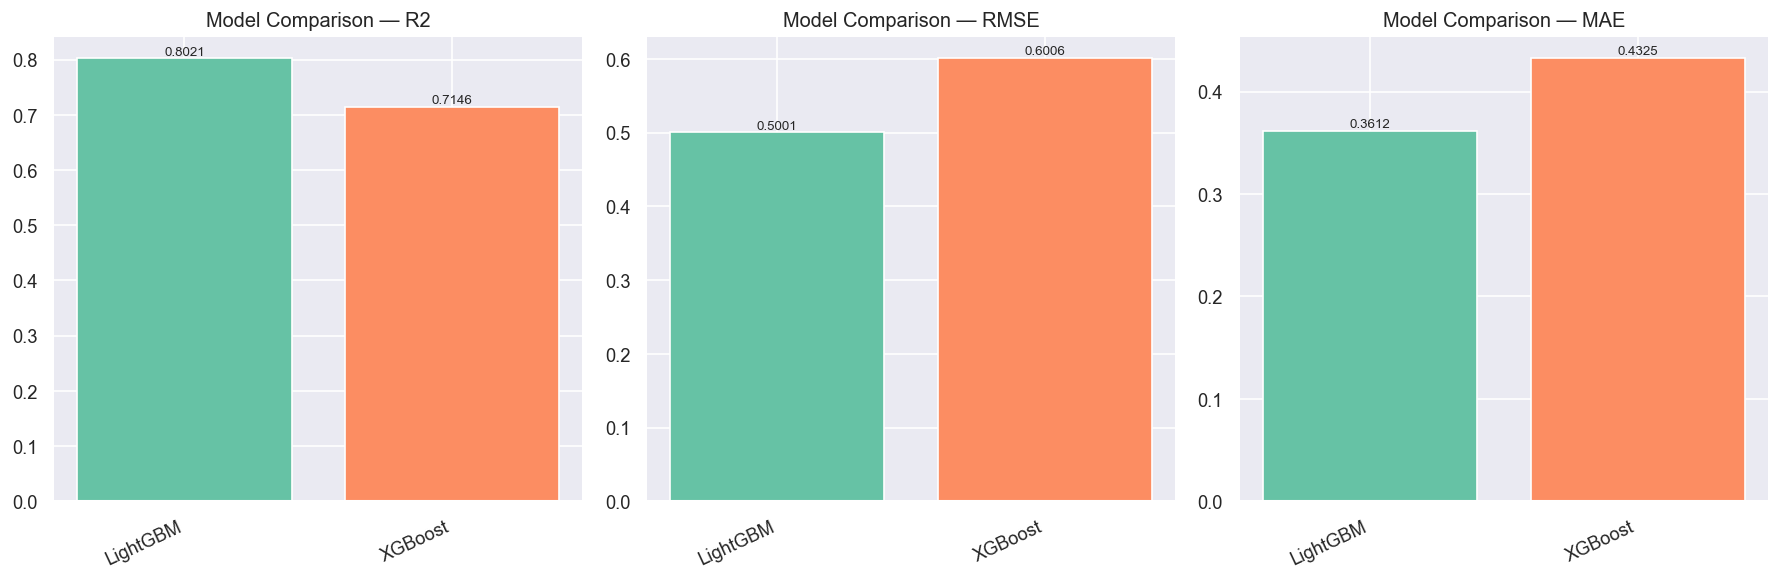

               R2      RMSE       MAE
LightGBM  0.80211  0.500098  0.361226
XGBoost   0.71457  0.600610  0.432460


In [48]:
metrics_df = pd.DataFrame(
    {k: {m: v for m, v in v.items() if m != 'pipeline'} for k, v in results.items()}
).T.sort_values('R2', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = sns.color_palette('Set2', len(metrics_df))

for ax, metric in zip(axes, ['R2', 'RMSE', 'MAE']):
    bars = ax.bar(metrics_df.index, metrics_df[metric], color=colors, edgecolor='white')
    ax.set_title(f'Model Comparison — {metric}', fontsize=12)
    ax.set_xticklabels(metrics_df.index, rotation=25, ha='right')
    for bar, val in zip(bars, metrics_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('plot_model_comparison.png', bbox_inches='tight')
plt.show()

print(metrics_df[['R2','RMSE','MAE']])

## 9. Best Model — Deeper Analysis

🏆 Best model: LightGBM  (R² = 0.8021)


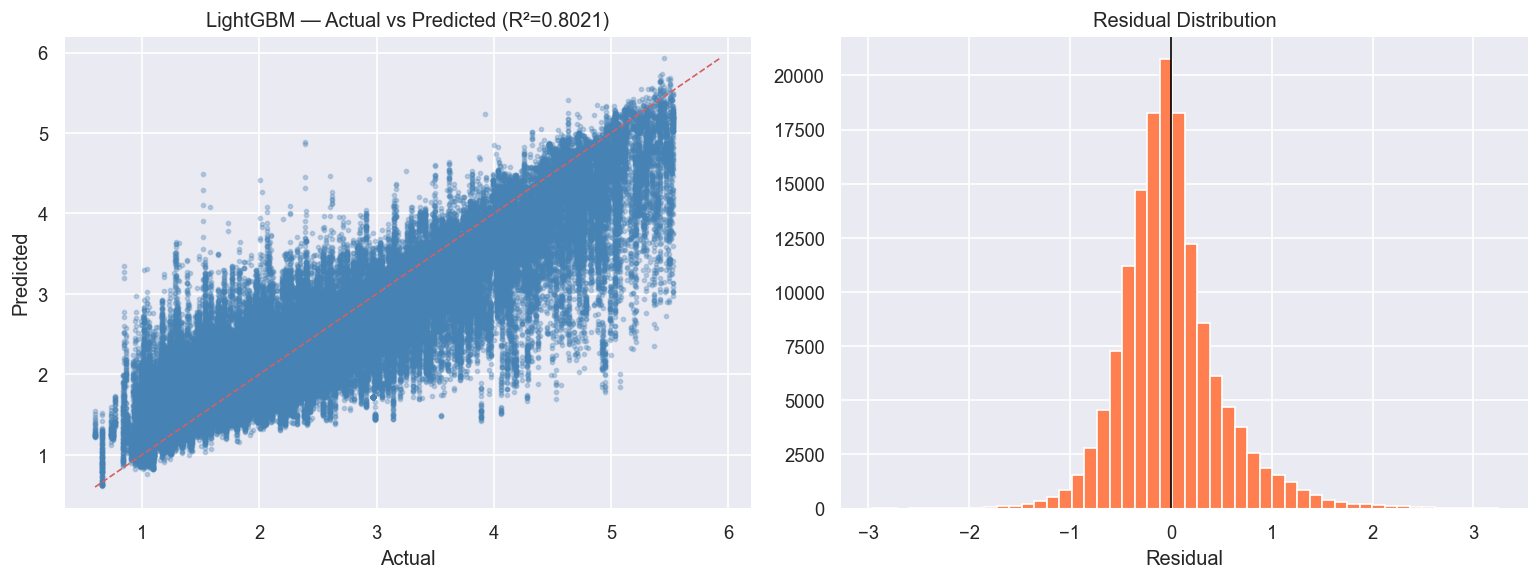

In [49]:
best_name = metrics_df['R2'].idxmax()
best_pipeline = results[best_name]['pipeline']
best_r2 = results[best_name]['R2']
print(f'🏆 Best model: {best_name}  (R² = {best_r2:.4f})')

best_preds = best_pipeline.predict(X_test)

# Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, best_preds, alpha=0.3, s=6, color='steelblue')
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')
axes[0].set_title(f'{best_name} — Actual vs Predicted (R²={best_r2:.4f})')

residuals = y_test - best_preds
axes[1].hist(residuals, bins=50, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('Residual'); axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig('plot_best_model_analysis.png', bbox_inches='tight')
plt.show()

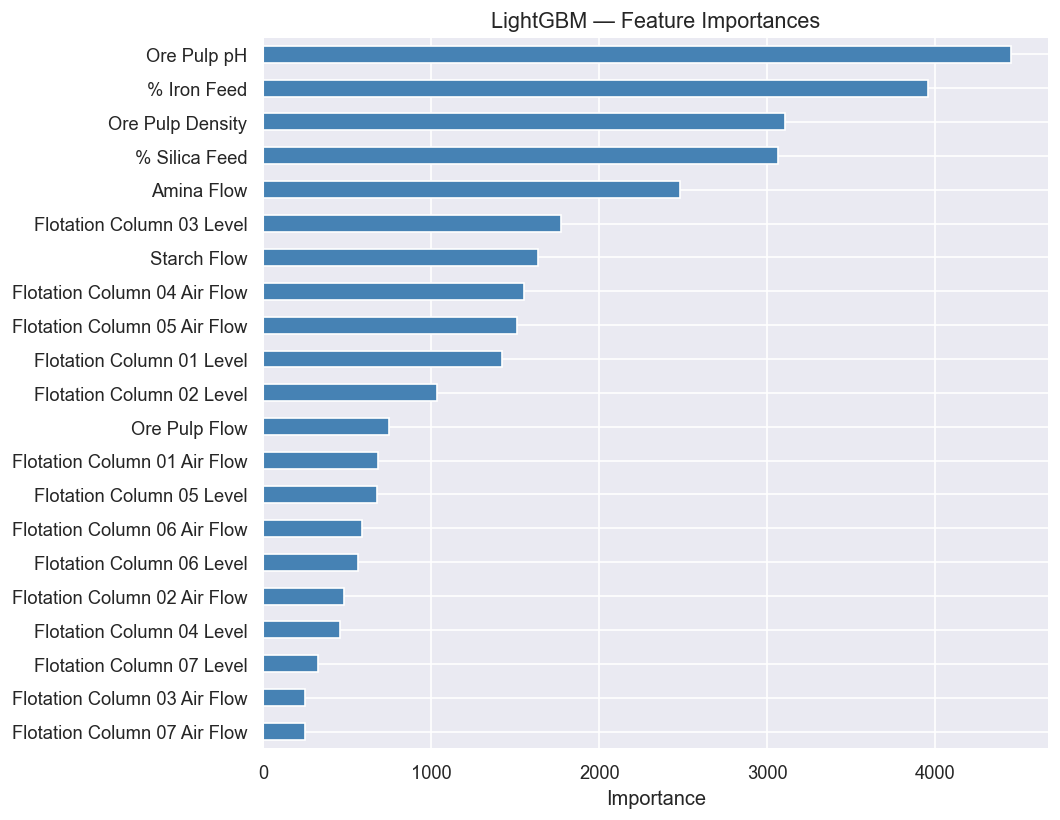

In [50]:
# Feature Importance (tree-based models only)
inner_model = best_pipeline.named_steps['model']
if hasattr(inner_model, 'feature_importances_'):
    fi = pd.Series(inner_model.feature_importances_, index=FEATURE_NAMES)
    fi = fi.sort_values(ascending=True)

    plt.figure(figsize=(9, 7))
    fi.plot(kind='barh', color='steelblue', edgecolor='white')
    plt.title(f'{best_name} — Feature Importances', fontsize=13)
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.savefig('plot_feature_importance.png', bbox_inches='tight')
    plt.show()
else:
    print(f'{best_name} does not expose feature importances.')

## 10. Package & Save Final Model

In [51]:
# Save the pipeline
joblib.dump(best_pipeline, 'best_model.pkl')

# Save metadata for Streamlit
meta = {
    'model_name': best_name,
    'r2_score': round(best_r2, 4),
    'rmse': round(results[best_name]['RMSE'], 4),
    'mae': round(results[best_name]['MAE'], 4),
    'features': FEATURE_NAMES,
    'target': TARGET,
    'feature_stats': df_imputed[FEATURE_NAMES].agg(['mean', 'std', 'min', 'max']).to_dict(),
    'all_results': {
        k: {'R2': round(v['R2'], 4), 'RMSE': round(v['RMSE'], 4), 'MAE': round(v['MAE'], 4)}
        for k, v in results.items()
    }
}

with open('model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Saved: best_model.pkl  +  model_meta.json ✅')
print(f'\n🏆 Final Model: {best_name}')
print(f'   R²   = {best_r2:.4f}')
print(f'   RMSE = {results[best_name]["RMSE"]:.4f}')
print(f'   MAE  = {results[best_name]["MAE"]:.4f}')

Saved: best_model.pkl  +  model_meta.json ✅

🏆 Final Model: LightGBM
   R²   = 0.8021
   RMSE = 0.5001
   MAE  = 0.3612


In [ ]:
#done
